In [43]:
import skysurvey
import numpy as np
from matplotlib import pyplot as plt

from lightcurve import generate_snia_lightcurve, plot_lightcurve, limit_mag_dict, get_valid_bands
from lightcurve import generate_snia_dict, generate_ordered_parameter_list, determine_visibility

import sncosmo

lsst_colors = ["tab:purple", "tab:green", "tab:orange", "tab:red", "tab:brown", "0.5"]
bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
snia_lightcurve_params = ["z", "x1", "c", "t0", "magabs", "ra", "dec"]

## TO DO 24 Jul 2026 / 06 Aug 2026
Remember: use random population to generate the event!
ref docs: https://skysurvey.readthedocs.io/en/latest/howto/load_lsst.html

1. Find coverage each night. Plot different nights.


After finding which points are detected, find the respective window

In [44]:
from skysurvey.config import get_band_color
import inspect
print(inspect.getsource(get_band_color))
help(get_band_color)

def get_band_color(bands, fill_value=None):
    """Get the color of the given bands.

    Parameters
    ----------
    bands: str or list of str
        Band or list of bands.
    fill_value: str or None, optional
        Value to fill if the band is not found.

    Returns
    -------
    str or list
        Color or list of colors.
    """
    squeeze = isinstance(bands, (str, np.str_))
    colors = [BAND_COLORS.get(band_, fill_value) for band_ in np.atleast_1d(bands)]
    return colors if not squeeze else colors[0]

Help on function get_band_color in module skysurvey.config:

get_band_color(bands, fill_value=None)
    Get the color of the given bands.

    Parameters
    ----------
    bands: str or list of str
        Band or list of bands.
    fill_value: str or None, optional
        Value to fill if the band is not found.

    Returns
    -------
    str or list
        Color or list of colors.



### Load LSST filepath
can take a while to load

In [ ]:
opsim_path = "baseline_v5.3.5_10yrs.db" # provide fullpath
# opsim_path = "Surveys/baseline_v5.3.5_10yrs.db:Zone.Identifier"
lsst = skysurvey.LSST.from_opsim(opsim_path, sql_where="night < 3650")
# if you want to choose only one band: band IN ('g') AND 
# IMPOTANT: remove the _## from the band names in the lsst observation
lsst.data["band"] = (lsst.data["band"].str.replace(r"_\d+$", "", regex=True))
lsst.data["band"].unique()

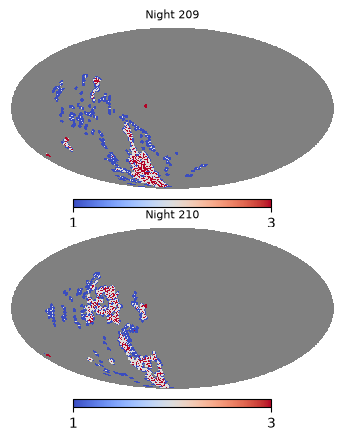

In [4]:
from lsst_functions import visualize_nights
visualize_nights(opsim_path, start_night=209, stop_night=211)

#### Plot nightly coverage and data
lsst_filter_designations = ['lsstu_24', 'lsstr_57', 'lsstg_6', 'lssti_39', 'lsstz_20', 'lssty_10']

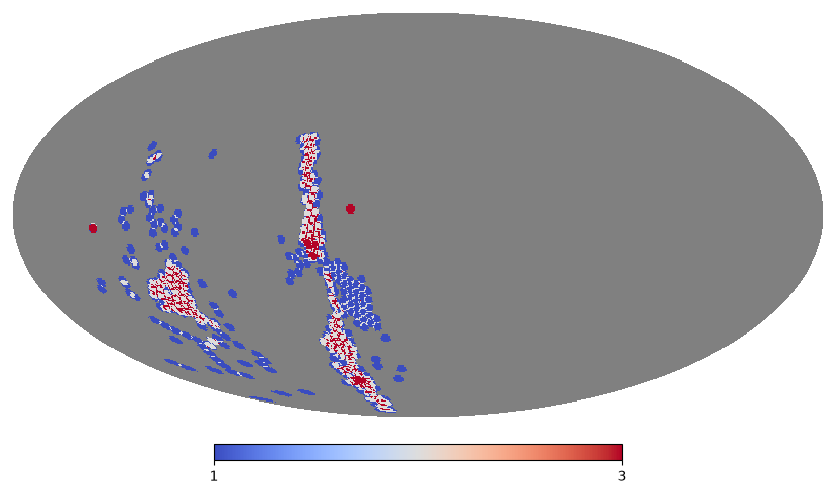

In [5]:
night_211 = skysurvey.LSST.from_opsim(opsim_path, sql_where= f"night >= 211 AND night < 212")
coverage_211 = night_211.get_fieldcoverage(incl_zeros=True)
night_211.show(vmin=0, vmax=coverage_211.quantile(0.95), cmap="coolwarm")

In [ ]:
print('fieldids with NaN value', coverage_211.isna().sum(),'| fieldids non-zero', coverage_211.notna().sum(), 'out of' , len(coverage_211)
      '\n min non-zero/max:', coverage_211.values.min(),  coverage_211.values.max())

fieldids with NaN value 452332 | fieldids non-zero 27668 out of 480000


In [39]:
coverage_211[coverage_211.values >= 0]

fieldid
118111    1.0
118112    1.0
118113    1.0
118114    1.0
118115    1.0
         ... 
478813    1.0
478814    1.0
478815    1.0
478816    1.0
478817    1.0
Length: 27668, dtype: float64

In [ ]:
# plot every five nights
for i in np.arange(2, 18, 5):
    night = skysurvey.LSST.from_opsim(opsim_path, sql_where= f"night >= {i} AND night < {i+5}")
    coverage = night.get_fieldcoverage()
    print(f'number of non-zero fieldids for {i} to {i+5}:', len(coverage.index))
    night.show(vmin=0, vmax=coverage.quantile(0.95), cmap="coolwarm", title = f'Night {i} to {i+5}')

In [5]:
lsst.data.columns

Index(['skynoise', 'mjd', 'band', 'gain', 'zp', 'ra', 'dec', 'observationId',
       'fieldid_survey', 'fieldid'],
      dtype='str')

In [ ]:
lsst.data #gives all info about the observation over the 1 year (e.g skynoise and in what band)
# left column is an exposure (in a certain obs_id/fieldid_survey), pointing at a particular field_ids

,skynoise,mjd,band,gain,zp,ra,dec,observationId,fieldid_survey,fieldid
0,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474007
1,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474008
2,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474009
3,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474010
4,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474011
...,...,...,...,...,...,...,...,...,...,...
19171321,36.069012,61566.074219,lsstr,1,30,196.431473,-47.600517,172627,172627,421827
19171322,36.069012,61566.074219,lsstr,1,30,196.431473,-47.600517,172627,172627,421828
19171323,36.069012,61566.074219,lsstr,1,30,196.431473,-47.600517,172627,172627,421829
19171324,36.069012,61566.074219,lsstr,1,30,196.431473,-47.600517,172627,172627,421830


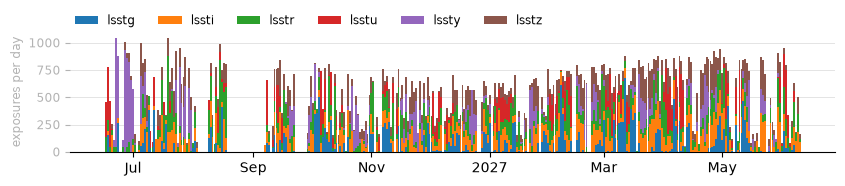

In [ ]:
fig = lsst.show_nexposures(exposure_key="observationId") #observationId is LSST's specific exposure_key
# and each exposure is for a certain number of minutes (usually five)

# (lsst.data["observationId"] == lsst.data["fieldid_survey"]).all() # should be true in our case. why?

In [ ]:
lsst.data[lsst.data['fieldid'] == 474009] #some have more observations than another
# as ['observationId'] increases, goes from u --> g --> r --> i --> z --> y
# fieldids can be duplicated too. this means that the same field was re-visited during different exposures

,skynoise,mjd,band,gain,zp,ra,dec,observationId,fieldid_survey,fieldid
2,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474009
729,71.667374,61208.203125,lsstu,1,30,265.602020,-77.358208,6,6,474009
1331,81.148010,61208.207031,lsstu,1,30,264.967010,-75.771973,11,11,474009
71531,94.095505,61209.132812,lsstu,1,30,260.472870,-76.249313,646,646,474009
479061,356.150421,61218.113281,lssty,1,30,263.992859,-75.561653,4315,4315,474009
712431,294.086578,61220.253906,lssty,1,30,268.981934,-77.110123,6417,6417,474009
716982,171.078552,61220.273438,lsstz,1,30,263.344421,-78.683006,6458,6458,474009
943122,200.201218,61226.015625,lsstz,1,30,258.859924,-78.667793,8503,8503,474009
1064015,57.544468,61227.054688,lsstr,1,30,265.298004,-78.184036,9595,9595,474009
1068970,54.989235,61227.074219,lsstr,1,30,265.698242,-77.884766,9639,9639,474009


In [ ]:
# differneces between cadences(exposures)
mjd_list = lsst.data["mjd"].unique() # mjd_list
diffs = []
for i in range(5):
    diff = mjd_list[i+1] - mjd_list[i]
    diffs.append(diff * 1440)

print("diff  (in minutes) is")
diffs

diff  (in minutes) is


[np.float32(5.625),
 np.float32(5.625),
 np.float32(67.5),
 np.float32(5.625),
 np.float32(5.625),
 np.float32(5.625),
 np.float32(5.625),
 np.float32(5.625),
 np.float32(5.625),
 np.float32(5.625)]

In [ ]:
# if you wan to vary time, 
from astropy.time import Time
tmin, tmax = lsst.date_range
print(f"Start: {Time(tmin, format='mjd').iso}")
print(f"End:   {Time(tmax, format='mjd').iso}")
print(f"Duration: {(tmax - tmin)/365.25:.1f} years")
lsst.date_range

Start: 2026-06-17 04:52:30.000
End:   2027-06-10 01:46:52.500
Duration: 1.0 years


(np.float32(61208.203), np.float32(61566.074))

In [41]:
snia_dict = generate_snia_dict(redshift = 0.7, ra = 14.9, dec = -22.4, x1 = 0.0, t0 = 61250.0, magabs = -18.523, c = 0.0)
snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = False, N_tot = 1000, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)
snia_models.template.get().maxtime()

np.float64(50.0)

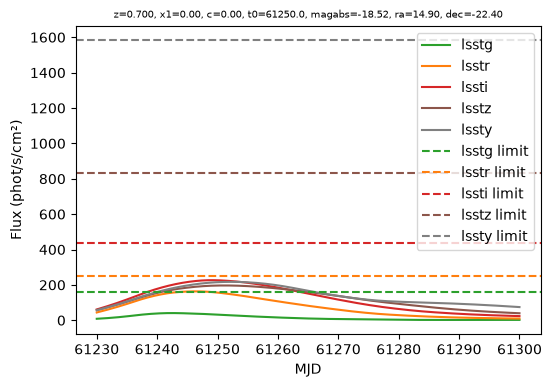

In [85]:
from lightcurve import plot_lightcurve
model = data_models[8]
plot_lightcurve(model, times=model['times'], in_mag = False)

In [ ]:
model['lc_by_band']['lssty']

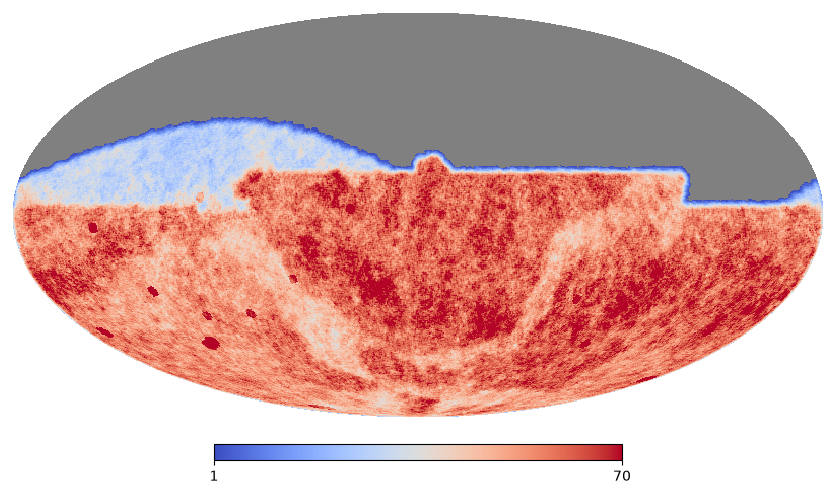

In [133]:
coverage = lsst.get_fieldcoverage()
lsst.show(vmin=0, vmax=coverage.quantile(0.95), cmap="coolwarm")

In [134]:
coverage[coverage == coverage.quantile(0.95)].index[1600] #336769

np.int32(336769)

In [44]:
select_fieldid = (lsst.data['fieldid'] == 336769)
lsst.data[select_fieldid]
#notice that the skynoise keeps changing

,skynoise,mjd,band,gain,zp,ra,dec,observationId,fieldid_survey,fieldid
746516,196.659775,61220.398438,lssty,1,30,15.118820,-24.520018,6728,6728,336769
747279,193.938110,61220.402344,lssty,1,30,13.439541,-24.830439,6735,6735,336769
748027,187.444550,61220.406250,lssty,1,30,14.914061,-22.415033,6741,6741,336769
2490977,174.023254,61249.308594,lssty,1,30,15.000562,-25.385891,22488,22488,336769
2493145,166.187485,61249.316406,lssty,1,30,12.824963,-23.767998,22507,22507,336769
...,...,...,...,...,...,...,...,...,...,...
11733574,529.284485,61455.027344,lsstz,1,30,13.848436,-23.457905,105804,105804,336769
11873313,235.430984,61459.015625,lsstr,1,30,14.848493,-22.415325,107059,107059,336769
11874778,234.476791,61459.019531,lsstr,1,30,14.848493,-22.415325,107072,107072,336769
11876243,214.955368,61459.019531,lsstr,1,30,14.848493,-22.415325,107085,107085,336769


<code>get_fieldcoverage()</code> returns the number of observations per field. Passing it to <code>show()</code> via vmax controls the color scale. In this example, we use the 95th percentile to enhance the constrast between fields that receive a high number of visits (e.g. deep drilling fields, overlap regions) and less-covered regions.

Once you simulated N_tot supernovae, the <code> .from_targets_and_survey() </code> function simulates the observation plan and sees if our SN are visible.
10/8/2026: Recall at ALL the SN are assumed to be at the same spot; so the fieldids where they are found in should match up.

Functions:

<code>get_targetlightcurve(index = ...)</code> gives a dataframe of diff index_obs with columns: field params.

In [ ]:
dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)
#discard_bands remove those which spectra do not fall within bands due to redshift

100%|██████████| 1000/1000 [00:06<00:00, 166.61it/s]


In [55]:
dset.get_ndetection(per_band = True).loc[0]
#same target but at what redshift? for the part of N detected points in lc, we can only simulate ONE.
# isn't it useless if you keep everything fixed for N_to = 1000? You need to vary t0.

band
lsstr    1
dtype: int64

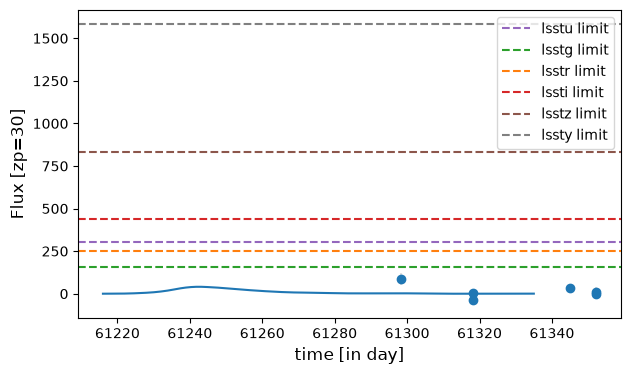

In [ ]:
dset.show_target_lightcurve(index = 6, phase_window=[-60,200], zp = 30, zpsys = 'ab', bands = ['lsstg'], format_time = False)
# plt.xlim(61321, 61322)
ax = plt.gca()
for band in bands:
    ax.axhline(
        limit_mag_dict[band]["flux"],
        color=limit_mag_dict[band]["color"],
        linestyle="--",
        label=f"{band} limit",
    )
ax.legend()

From these, you want to build a dataframe of all the observations.
pandas.DataFrame format:

Blank | filters ..... | ..... |
Cond 1   1, 0, or -1 depending on visiblity (already possible using determine_visiblity())
Cond 2   same
Cond 3   same

In [ ]:
from lightcurve import limit_mag_dict

def get_band_data(target_data, band = None):
    # for observation dataset of one target
    return target_data[target_data['band'] == band]

def get_unique_bands(target_data):
    return target_data['flux'].unique()

In [ ]:
import pandas as pd

def make_visibility_row(lc_by_band, limit_mag_dict = limit_mag_dict, in_mag = True):
    #initialise every band as -1 meaning not available.
    row = {band: 0 for band in limit_mag_dict}
    
    for band, y_vals in lc_by_band.items():
        if in_mag:
            row[band] = int(
                np.any(np.asarray(y_vals) < limit_mag_dict[band]["mag"])
            ) #returns 0 (falls within filter wavelength range but too faint), 1 if visible
        else:
            row[band] = int(
                np.any(np.asarray(y_vals) < limit_mag_dict[band]["flux"])
            )

    return row

def five_sigma_detection_by_band(dataset, targets, index=0):
    z = targets.data.loc[index, "z"]

    valid_bands = get_valid_bands(model=targets.template.sncosmo_model,redshift=z,bands=lsst_bands,)
    # row = {band: -1 if band not in valid_bands else 0 for band in lsst_bands} #initialise row dict as 0

    row = {band: 0 for band in lsst_bands}
    detection_rows = dataset.get_data(index=index,detection=True)

    for band in valid_bands:
        band_data = detection_rows[detection_rows["band"] == band]
        if len(band_data) > 0:
            row[band] = 1

    return row

def flux_limit_detection_by_band(dataset, targets, index=0):
    """
    Third condition: skysurvey five-sigma AND above our flux limit.
    """
    z = targets.data.loc[index, "z"]
    valid_bands = get_valid_bands(model=targets.template.sncosmo_model,redshift=z,bands=lsst_bands)
    # row = {band: 0 if band not in valid_bands else 0 for band in lsst_bands}
    row = {band: 0 for band in lsst_bands}

    detection_rows = dataset.get_data(index=index,detection=True,).copy()

    if len(detection_rows) == 0:
        return row

    flux_lookup = {band: limit_mag_dict[band]["flux"] for band in limit_mag_dict}

    detection_rows["limit_flux"] = detection_rows["band"].map(flux_lookup)

    for band in valid_bands:
        band_data = detection_rows[detection_rows["band"] == band]
        if np.any(band_data["flux"] >= band_data["limit_flux"]):
            row[band] = 1
        
    return row


def compare_detection_conditions(dataset,targets,data_models,index=0):

    theoretical = determine_visibility(data_models[index],return_dict=True,in_mag=False,)
    five_sigma = five_sigma_detection_by_band(dataset,targets,index=index)
    flux_limit = flux_limit_detection_by_band(dataset,targets,index=index,)

    result = pd.DataFrame(
        [theoretical, five_sigma, flux_limit],
        index =["theoretical","5_sigma","5_sigma_flux_limit",],)

    result.index.name = "condition"
    result.insert(0, "target", index)

    return result.reset_index()

In [ ]:
# for ONE index (i.e. index == 10)

result = compare_detection_conditions(dataset=dset,targets=snia_models,data_models=data_models,index=10)
result

# these are for MULTIPLE TARGETS WITH EVERY PARAM SAME.
# To do next: You still need to stack this (i.e. the values below each band column is the counts of detected SNIa)

# To do next (after 16 Aug 2026): For ONE target, focus on datapoint counts to see how many data points are visible

,condition,target,lsstu,lsstg,lsstr,lssti,lsstz,lssty
0,theoretical,10,0,1,1,0,0,0
1,5_sigma,10,0,0,1,0,0,0
2,5_sigma_flux_limit,10,0,0,0,0,0,0


In [ ]:
# stack all 1000 SNIa targets
all_results = []

for index in snia_models.data.index:
    result = compare_detection_conditions(dataset=dset,targets=snia_models,data_models=data_models,index=index)
    all_results.append(result)

all_results = pd.concat(all_results,ignore_index=True)

In [ ]:
all_results[
    (all_results["condition"] == "5_sigma") &
    (all_results["lsstr"] == 1) # seen in that particular filter
].head()

,condition,target,lsstu,lsstg,lsstr,lssti,lsstz,lssty
1,5_sigma,0,0,0,1,0,0,0
4,5_sigma,1,0,0,1,0,0,0
25,5_sigma,8,0,0,1,0,0,0
31,5_sigma,10,0,0,1,0,0,0
55,5_sigma,18,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...
2941,5_sigma,980,0,0,1,0,0,0
2950,5_sigma,983,0,0,1,0,0,0
2959,5_sigma,986,0,0,1,0,0,0
2989,5_sigma,996,0,0,1,0,0,0


In [ ]:
all_results.groupby("condition")[lsst_bands].sum()

In [ ]:
summary = (all_results.groupby("condition")[lsst_bands].sum().reset_index())

In [268]:
summary

,condition,z,x1,c,t0,magabs,ra,dec,lsstu,lsstg,lsstr,lssti,lsstz,lssty
0,5_sigma,0.8,0.0,0.0,61250.0,-18.523001,14.9,-22.4,0,0,0,0,0,0
1,5_sigma_flux_limit,0.8,0.0,0.0,61250.0,-18.523001,14.9,-22.4,0,0,0,0,0,0
2,theoretical,0.8,0.0,0.0,61250.0,-18.523001,14.9,-22.4,-100,100,100,100,100,100


#### plot avg. no of SOURCES DETECTED against redshift

If you want to display a target's params: <code>snia_models.data.loc[1].to_frame().T</code>

In [269]:
N_tot = 1000
all_summaries = []
# [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
for redshift in [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]:

    snia_dict = generate_snia_dict(redshift=redshift, ra=14.9, dec=-22.4, x1=0.0, t0=61250.0, magabs=-18.523,c=0.0)

    snia_param_list = generate_ordered_parameter_list(input_dict=True,params=snia_dict)

    snia_models, data_models = generate_snia_lightcurve(*snia_param_list,bands=bands,in_mag=False,N_tot=N_tot,zp=30,plot_curve=False,return_values=True,return_models=True,verbose=False)

    dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst,progress_bar=True,discard_bands=True)

    # Get detection results for every target
    target_results = []

    for index in snia_models.data.index:

        result = compare_detection_conditions(dataset=dset,targets=snia_models,data_models=data_models,index=index)

        target_results.append(result)

    target_results = pd.concat(target_results,ignore_index=True)

    # Sum detections over all targets
    summary = (target_results.groupby("condition")[lsst_bands].sum().reset_index())

    # Convert to average number of detections per target
    summary[lsst_bands]

    # Add redshift
    summary["z"] = redshift

    # Add the other fixed parameters
    for col in ["x1", "c", "t0", "magabs", "ra", "dec"]:
        summary[col] = snia_models.data[col].iloc[0]

    # Keep useful column order
    summary = summary[["condition", "z","x1","c","t0","magabs","ra","dec"] + lsst_bands]
    all_summaries.append(summary)

# Combine all redshifts
final_summary = pd.concat(all_summaries,ignore_index=True)

print(final_summary)

100%|██████████| 1000/1000 [00:06<00:00, 162.50it/s]


             condition     z   x1    c       t0     magabs    ra   dec  lsstu  \
0              5_sigma  0.01  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1000   
1   5_sigma_flux_limit  0.01  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1000   
2          theoretical  0.01  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1000   
3              5_sigma  0.05  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1000   
4   5_sigma_flux_limit  0.05  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1000   
5          theoretical  0.05  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1000   
6              5_sigma  0.10  0.0  0.0  61250.0 -18.523001  14.9 -22.4    948   
7   5_sigma_flux_limit  0.10  0.0  0.0  61250.0 -18.523001  14.9 -22.4    948   
8          theoretical  0.10  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1000   
9              5_sigma  0.20  0.0  0.0  61250.0 -18.523001  14.9 -22.4      0   
10  5_sigma_flux_limit  0.20  0.0  0.0  61250.0 -18.523001  14.9 -22.4      0   
11         theoretical  0.20

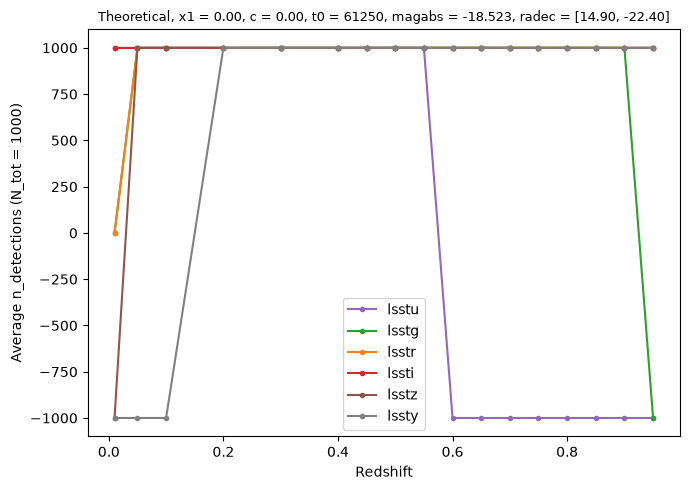

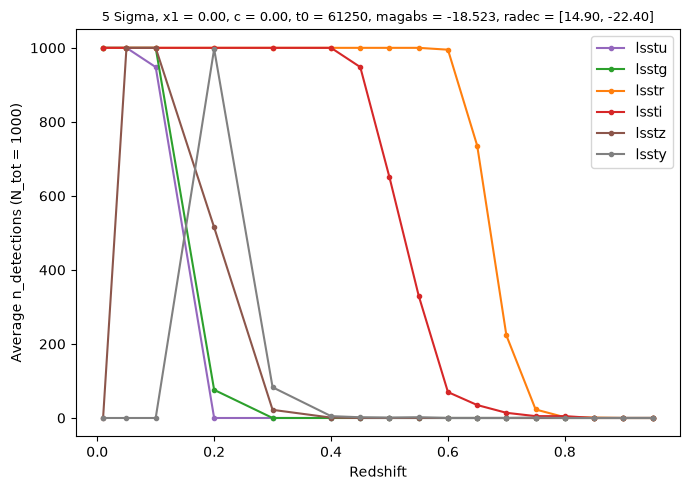

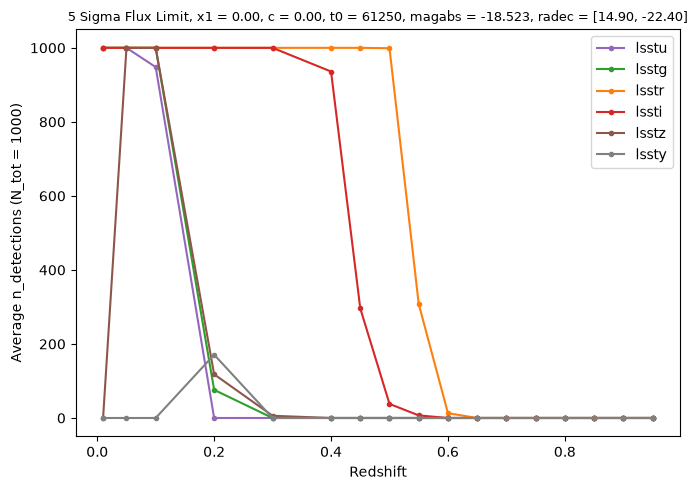

In [270]:
for condition in ["theoretical", "5_sigma", "5_sigma_flux_limit"]:

    fig, ax = plt.subplots(figsize=(7, 5))
    # subset: chose one criterion
    subset = final_summary[final_summary["condition"] == condition]
    x1 = subset["x1"].iloc[0]
    c = subset["c"].iloc[0]
    t0 = subset["t0"].iloc[0]
    magabs = subset["magabs"].iloc[0]
    ra = subset["ra"].iloc[0]
    dec = subset["dec"].iloc[0]

    for band in lsst_bands:
        ax.plot(subset["z"],subset[band],marker=".",label=band,color=limit_mag_dict[band]["color"])
        
    ax.set_xlabel("Redshift")
    ax.set_ylabel("Average n_detections (N_tot = {})".format(N_tot))
    ax.set_title(
        f"{condition.replace('_', ' ').title()}, "
        f"x1 = {x1:.2f}, c = {c:.2f}, "
        f"t0 = {t0:.0f}, magabs = {magabs:.3f}, "
        f"radec = [{ra:.2f}, {dec:.2f}]",
        fontsize=9,
    )
    ax.legend()

    plt.tight_layout()
    plt.show()

#### Valid bands are only useful for the # sources detected section

In [ ]:
from lightcurve import get_valid_bands, lsst_bands
valid_bands = get_valid_bands(model=snia_models.template.sncosmo_model, redshift=snia_models.data.loc[10, "z"], bands=lsst_bands)
valid_bands

In [205]:
get_valid_bands(snia_models.template.sncosmo_model, redshift = snia_models.data.loc[10], bands = lsst_bands)
# dset.get_data(index = 10, detection = False) # will be the same for ALL indices (targets) since same params --> same theoretical LCs

['lsstg', 'lsstr', 'lssti', 'lsstz', 'lssty']

In [151]:
target = dset.data.loc[10]
target[target['band'].isin(['lsstg', 'lsstr', 'lsstu'])]

,mjd,band,skynoise,gain,zp,fieldid,flux,fluxerr
index_obs,,,,,,,,
2770824,61261.406250,lsstr,24.485266,1,30,331967,133.759742,26.443373
2772648,61261.421875,lsstr,24.718338,1,30,331967,138.515773,26.657840
3332454,61269.425781,lsstr,48.146404,1,30,331967,87.245380,48.787638
3876993,61298.285156,lsstg,36.171204,1,30,331967,51.304449,36.205593
3880803,61298.304688,lsstr,33.454300,1,30,331967,-33.137521,33.609057
4038673,61301.277344,lsstr,47.049492,1,30,331967,-64.242119,47.148432
4707663,61318.281250,lsstg,24.247990,1,30,331967,18.905738,24.249050
4708517,61318.281250,lsstg,21.828072,1,30,331967,22.686462,21.829249
5936096,61345.054688,lsstg,20.342854,1,30,331967,-3.653009,20.342854


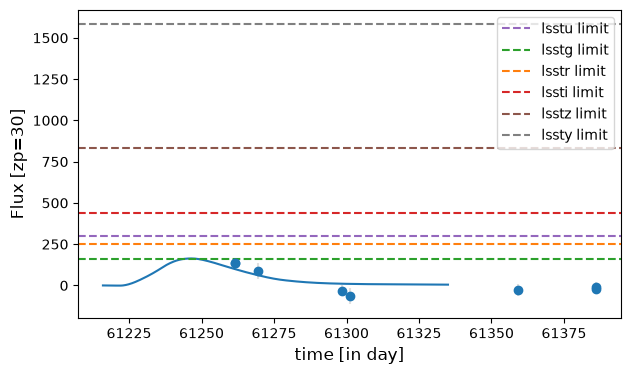

In [156]:
dset.show_target_lightcurve(index = 10, phase_window=[-60,200], zp = 30, bands = ['lsstr'], format_time = False)
# plt.xlim(61321, 61322)
ax = plt.gca()
for band in bands:
    ax.axhline(
        limit_mag_dict[band]["flux"],
        color=limit_mag_dict[band]["color"],
        linestyle="--",
        label=f"{band} limit",
    )
ax.legend()

In [110]:
# then, from the number of points, append it into n_detections
# (condition 2: with get_ndetections and condition 3: with get_ndetections AND filter limit)

,mjd,band,skynoise,gain,zp,fieldid,flux,fluxerr,band_limitflux,SNR
index_obs,,,,,,,,,,
747982,61220.406250,lssty,187.444550,1,30,331967,431.861593,187.450856,1584.893,2.303866
884609,61222.398438,lssty,263.259705,1,30,331967,509.045209,263.270616,1584.893,1.933544
2493070,61249.316406,lssty,169.995941,1,30,331967,167.708086,170.624301,1584.893,0.982909
2770824,61261.406250,lsstr,24.485266,1,30,331967,133.759742,26.443373,251.189,5.058346
2772648,61261.421875,lsstr,24.718338,1,30,331967,138.515773,26.657840,251.189,5.196061
2860934,61262.421875,lssti,57.493050,1,30,331967,210.770241,58.940588,436.516,3.575978
3332454,61269.425781,lsstr,48.146404,1,30,331967,87.245380,48.787638,251.189,1.788268
3429213,61270.429688,lsstz,211.943130,1,30,331967,-119.422057,212.261963,831.764,-0.562616
3623916,61295.328125,lssti,76.185585,1,30,331967,75.774563,76.372389,436.516,0.992172


## Ok, now do for just one lightcurve

Note: we will use the average over 100 observations (due to random nature of noise + errors)
to establish the expected number of points detected.

In [ ]:
snia_dict = generate_snia_dict(redshift = 0.4, ra = 14.9, dec = -22.4, x1 = 0.0, t0 = 61250.0, magabs = -18.523, c = 0.0)
snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = False, N_tot = 100, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)

In [80]:
lsst.data.columns.to_list()

['skynoise',
 'mjd',
 'band',
 'gain',
 'zp',
 'ra',
 'dec',
 'observationId',
 'fieldid_survey',
 'fieldid']

In [81]:
dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)

100%|██████████| 100/100 [00:01<00:00, 51.85it/s]


In [82]:
detection = dset.get_ndetection(per_band = True, join_bandday = False)

In [96]:
detection.loc[0]

band
lssti    1
lsstr    3
dtype: int64

In [ ]:
detections = dset.get_data(index = 0,detection=True)
detections

,mjd,band,skynoise,gain,zp,fieldid,flux,fluxerr
index_obs,,,,,,,,
2770824,61261.406250,lsstr,24.485266,1,30,331967,525.988070,33.034356
2772648,61261.421875,lsstr,24.718338,1,30,331967,516.984616,33.201154
2860934,61262.421875,lssti,57.493050,1,30,331967,532.860259,61.926451
3332454,61269.425781,lsstr,48.146404,1,30,331967,296.437637,51.115949


In [143]:
test = detections.iloc[0]
test

mjd         61261.40625
band              lsstr
skynoise      24.485266
gain                  1
zp                   30
fieldid          331967
flux          525.98807
fluxerr       33.034356
Name: 2770824, dtype: object

In [144]:
def flux_to_mag(flux, zp=30):
    return zp - 2.5*np.log10(flux)

def mag_to_flux(mag, zp=30):
    return 10**(-0.4*(mag-zp))

In [145]:
skynoise = test['skynoise']
flux = test['flux'] + np.random.normal(loc = 0, scale = 0)
gain = 1
fluxerr = np.sqrt(skynoise ** 2 + np.abs(flux / gain))
fluxerr
# def get_magnitude_obs():

np.float64(33.548715757345846)

In [146]:
flux_at_5sig = fluxerr * 5
print(flux_at_5sig)
limit_mag = flux_to_mag(flux_at_5sig, zp = 30)
limit_mag #in my current example: i used lsstr



167.74357878672924


np.float64(24.438385239013158)

In [130]:
test = detections.iloc[2]
skynoise = test['skynoise']
flux = test['flux'] + np.random.normal(loc = 0, scale = 62)
gain = 1
fluxerr = np.sqrt(skynoise ** 2 + np.abs(flux / gain))
flux_at_5sig = fluxerr * 5
print(flux_at_5sig)
limit_mag = flux_to_mag(flux_at_5sig, zp = 30)
limit_mag #in my current example: i used lsstr
# def get_magnitude_obs():

310.63693607499897


np.float64(23.769367265113004)

In [124]:
from skysurvey.tools.utils import get_skynoise_from_maglimit

skynoise = get_skynoise_from_maglimit(24.13, zp=30)
skynoise

44.568702985406105

In [126]:
limit_skynoise_dict = {
    band: get_skynoise_from_maglimit(
        info["mag"],
        zp=30
    )
    for band, info in limit_mag_dict.items()
}

In [127]:
limit_skynoise_dict

{'lsstu': 60.39903440804032,
 'lsstg': 31.697863849222284,
 'lsstr': 50.23772863019165,
 'lssti': 87.30316644803331,
 'lsstz': 166.35275422053434,
 'lssty': 316.9786384922228}

In [127]:
snia_lightcurve_params = ['redshift', 'x1', 'c', 't0', 'magabs', 'ra', 'dec']

In [164]:
from lightcurve import lsst_bands

def get_number_detections_band_five_sigma(dataset, targets, index=0):
    z = targets.data.loc[index, "z"]

    # valid_bands = get_valid_bands(model=targets.template.sncosmo_model,redshift=z,bands=lsst_bands,)
    # row = {band: -1 if band not in valid_bands else 0 for band in lsst_bands} #initialise row dict as 0

    row = {band: 0 for band in lsst_bands} #initiate
    detection_rows = dataset.get_data(index=index,detection=True)

    for band in lsst_bands:
        band_data = detection_rows[detection_rows["band"] == band]
        row[band] = len(band_data)

    return row

def get_number_detections_band_flux_limit(dataset, targets, index=0):
    """
    Third condition: skysurvey five-sigma AND above our flux limit.
    """
    # z = targets.data.loc[index, "z"]
    # valid_bands = get_valid_bands(model=targets.template.sncosmo_model,redshift=z,bands=lsst_bands)
    # row = {band: 0 if band not in valid_bands else 0 for band in lsst_bands}
    row = {band: 0 for band in lsst_bands}
    detection_rows = dataset.get_data(index=index,detection=True).copy()

    if len(detection_rows) == 0:
        return row

    flux_lookup = {band: limit_mag_dict[band]["flux"] for band in limit_mag_dict}
    detection_rows["limit_flux"] = detection_rows["band"].map(flux_lookup)

    for band in lsst_bands:
        band_data = detection_rows[detection_rows["band"] == band]
        filtered_data = band_data[band_data["flux"] >= band_data["limit_flux"]]
        row[band] = len(filtered_data)
    return row


def compare_ndetections_by_condition(dataset,targets, index=0):
    """
    Just two conditions since theoretical lightcurve does not give discrete datapoints (there is actl 500 but says nothing about obs style)
    
    data_model: snia_model.data
    """
    if targets is None:
        raise ValueError('Input model required.')
    
    five_sigma = get_number_detections_band_five_sigma(dataset,targets,index=index,)

    flux_limit = get_number_detections_band_flux_limit(dataset,targets,index=index,)

    result = pd.DataFrame(
        [five_sigma, flux_limit],
        index=["5_sigma", "5_sigma_flux_limit"]
    )

    result.index.name = "condition"

    metadata = {}
    metadata["target"] = index
    metadata["z"] = targets.data["z"].loc[index]  # Get z from data, not hardcoded
   

    for param in ['x1', 'c', 't0', 'magabs', 'ra', 'dec']:
        metadata[param] = targets.data[param].loc[index]
    
    # Insert all metadata columns at the beginning
    for col_name, col_value in metadata.items():
        result.insert(0, col_name, col_value)

    return result.reset_index()

In [165]:
get_number_detections_band_five_sigma(dset, snia_models, index=30)


{'lsstu': 0, 'lsstg': 0, 'lsstr': 3, 'lssti': 1, 'lsstz': 0, 'lssty': 0}

In [166]:
get_number_detections_band_flux_limit(dset, snia_models, index=30)

{'lsstu': 0, 'lsstg': 0, 'lsstr': 3, 'lssti': 1, 'lsstz': 0, 'lssty': 0}

In [167]:
result = compare_ndetections_by_condition(dset, snia_models, index=30)
result

,condition,dec,ra,magabs,t0,c,x1,z,target,lsstu,lsstg,lsstr,lssti,lsstz,lssty
0,5_sigma,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,30,0,0,3,1,0,0
1,5_sigma_flux_limit,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,30,0,0,3,1,0,0


In [178]:
all_results = []

for index in snia_models.data.index:
    result = compare_ndetections_by_condition(dataset=dset,targets=snia_models,index=index)
    all_results.append(result)

all_results = pd.concat(all_results,ignore_index=True)
all_results

,condition,dec,ra,magabs,t0,c,x1,z,target,lsstu,lsstg,lsstr,lssti,lsstz,lssty
0,5_sigma,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,0,0,0,2,1,0,0
1,5_sigma_flux_limit,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,0,0,0,2,1,0,0
2,5_sigma,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,1,0,0,3,1,0,0
3,5_sigma_flux_limit,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,1,0,0,3,1,0,0
4,5_sigma,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,2,0,0,3,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,5_sigma_flux_limit,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,97,0,0,3,1,0,0
196,5_sigma,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,98,0,0,2,1,0,0
197,5_sigma_flux_limit,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,98,0,0,2,1,0,0
198,5_sigma,-22.4,14.9,-18.523001,61250.0,0.0,0.0,0.4,99,0,0,3,1,0,0


In [ ]:
all_results[
    (all_results["condition"] == "5_sigma") &
    (all_results["lsstr"] == 1) # seen in that particular filter
].head()

all_results.groupby("condition")[lsst_bands].sum()


,lsstu,lsstg,lsstr,lssti,lsstz,lssty
condition,,,,,,
5_sigma,0,0,273,99,0,0
5_sigma_flux_limit,0,0,273,98,0,0


In [ ]:
N_tot = 100

summary = (all_results.groupby("condition")[lsst_bands].sum().reset_index())

# Average number of detections per target
summary[lsst_bands] /= n_targets

# Parameters — assuming they are fixed across all targets
for col in ["z", "x1", "c", "t0", "magabs", "ra", "dec"]:
    summary[col] = all_results[col].iloc[0]

summary = summary[
    ["condition","z","x1","c","t0","magabs","ra","dec"] + lsst_bands
]

In [ ]:
for band in lsst_bands:
    print(summary[band][0]) # to get the values of cond1
    print(summary[band][1]) # to get the values of cond2 

IndexError: invalid index to scalar variable.

In [227]:
summary

,condition,z,x1,c,t0,magabs,ra,dec,lsstu,lsstg,lsstr,lssti,lsstz,lssty
0,5_sigma,0.6,0.0,0.0,61250.0,-18.523001,14.9,-22.4,0.0,0.0,1.81,0.06,0.0,0.0
1,5_sigma_flux_limit,0.6,0.0,0.0,61250.0,-18.523001,14.9,-22.4,0.0,0.0,0.01,0.00,0.0,0.0


In [213]:
N_tot = 100
for redshift in [0.2, 0.4, 0.6]:
    snia_dict = generate_snia_dict(redshift = redshift, ra = 14.9, dec = -22.4, x1 = 0.0, t0 = 61250.0, magabs = -18.523, c = 0.0)
    snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
    snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = False, N_tot = N_tot, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)
    dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)
    detection = dset.get_ndetection(per_band = True, join_bandday = False)

    N_tot = 100
    all_results = []

    for index in snia_models.data.index:
        result = compare_ndetections_by_condition(dataset=dset,targets=snia_models,index=index)
        all_results.append(result)

    all_results = pd.concat(all_results,ignore_index=True)
    all_results
    summary = (all_results.groupby("condition")[lsst_bands].sum().reset_index())

    # Average number of detections per target
    summary[lsst_bands] /= n_targets

    # Parameters — assuming they are fixed across all targets
    for col in ["z", "x1", "c", "t0", "magabs", "ra", "dec"]:
        summary[col] = all_results[col].iloc[0]

    summary = summary[
        ["condition","z","x1","c","t0","magabs","ra","dec"] + lsst_bands
    ]
    print(summary)

100%|██████████| 100/100 [00:14<00:00,  6.79it/s]


            condition    z   x1    c       t0     magabs    ra   dec  lsstu  \
0             5_sigma  0.2  0.0  0.0  61250.0 -18.523001  14.9 -22.4    0.0   
1  5_sigma_flux_limit  0.2  0.0  0.0  61250.0 -18.523001  14.9 -22.4    0.0   

   lsstg  lsstr  lssti  lsstz  lssty  
0    0.1   4.98   4.67   0.55   1.00  
1    0.1   4.98   3.98   0.15   0.29  


100%|██████████| 100/100 [00:03<00:00, 28.64it/s]


            condition    z   x1    c       t0     magabs    ra   dec  lsstu  \
0             5_sigma  0.4  0.0  0.0  61250.0 -18.523001  14.9 -22.4    0.0   
1  5_sigma_flux_limit  0.4  0.0  0.0  61250.0 -18.523001  14.9 -22.4    0.0   

   lsstg  lsstr  lssti  lsstz  lssty  
0    0.0   2.79   1.00    0.0   0.01  
1    0.0   2.79   0.94    0.0   0.00  


100%|██████████| 100/100 [00:03<00:00, 26.04it/s]


            condition    z   x1    c       t0     magabs    ra   dec  lsstu  \
0             5_sigma  0.6  0.0  0.0  61250.0 -18.523001  14.9 -22.4    0.0   
1  5_sigma_flux_limit  0.6  0.0  0.0  61250.0 -18.523001  14.9 -22.4    0.0   

   lsstg  lsstr  lssti  lsstz  lssty  
0    0.0   1.81   0.06    0.0    0.0  
1    0.0   0.01   0.00    0.0    0.0  


In [ ]:
N_tot = 100
all_summaries = []

for redshift in [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]:

    snia_dict = generate_snia_dict(redshift=redshift, ra=14.9, dec=-22.4, x1=0.0, t0=61250.0, magabs=-18.523,c=0.0)

    snia_param_list = generate_ordered_parameter_list(input_dict=True,params=snia_dict)

    snia_models, data_models = generate_snia_lightcurve(*snia_param_list,bands=bands,in_mag=False,N_tot=N_tot,zp=30,plot_curve=False,return_values=True,return_models=True,verbose=False)

    dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst,progress_bar=True,discard_bands=True)

    # Get detection results for every target
    target_results = []

    for index in snia_models.data.index:

        result = compare_ndetections_by_condition(
            dataset=dset,
            targets=snia_models,
            index=index
        )

        target_results.append(result)

    target_results = pd.concat(
        target_results,
        ignore_index=True
    )

    # Sum detections over all targets
    summary = (
        target_results
        .groupby("condition")[lsst_bands]
        .sum()
        .reset_index()
    )

    # Convert to average number of detections per target
    summary[lsst_bands] /= N_tot

    # Add redshift
    summary["z"] = redshift

    # Add the other fixed parameters
    for col in ["x1", "c", "t0", "magabs", "ra", "dec"]:
        summary[col] = snia_models.data[col].iloc[0]

    # Keep useful column order
    summary = summary[
        [
            "condition",
            "z",
            "x1",
            "c",
            "t0",
            "magabs",
            "ra",
            "dec"
        ] + lsst_bands
    ]

    all_summaries.append(summary)

# Combine all redshifts
final_summary = pd.concat(
    all_summaries,
    ignore_index=True
)

print(final_summary)

100%|██████████| 100/100 [00:01<00:00, 73.10it/s]


             condition     z   x1    c       t0     magabs    ra   dec  lsstu  \
0              5_sigma  0.01  0.0  0.0  61250.0 -18.523001  14.9 -22.4   6.00   
1   5_sigma_flux_limit  0.01  0.0  0.0  61250.0 -18.523001  14.9 -22.4   6.00   
2              5_sigma  0.05  0.0  0.0  61250.0 -18.523001  14.9 -22.4   6.00   
3   5_sigma_flux_limit  0.05  0.0  0.0  61250.0 -18.523001  14.9 -22.4   6.00   
4              5_sigma  0.10  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1.01   
5   5_sigma_flux_limit  0.10  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1.01   
6              5_sigma  0.20  0.0  0.0  61250.0 -18.523001  14.9 -22.4   0.00   
7   5_sigma_flux_limit  0.20  0.0  0.0  61250.0 -18.523001  14.9 -22.4   0.00   
8              5_sigma  0.30  0.0  0.0  61250.0 -18.523001  14.9 -22.4   0.00   
9   5_sigma_flux_limit  0.30  0.0  0.0  61250.0 -18.523001  14.9 -22.4   0.00   
10             5_sigma  0.40  0.0  0.0  61250.0 -18.523001  14.9 -22.4   0.00   
11  5_sigma_flux_limit  0.40

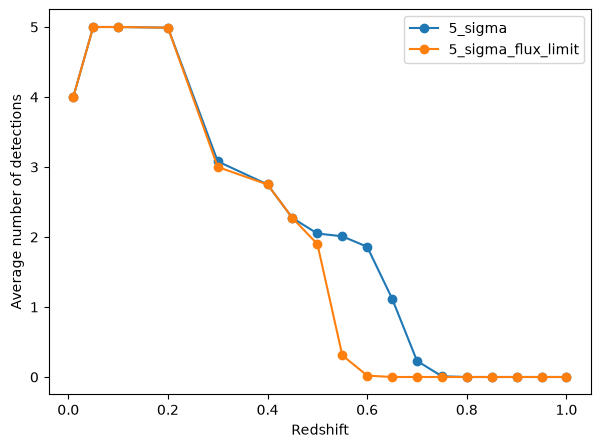

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

for condition in ["5_sigma", "5_sigma_flux_limit"]:

    subset = final_summary[
        final_summary["condition"] == condition
    ]

    ax.plot(
        subset["z"],
        subset["lsstr"],
        marker="o",
        label=condition
    )

ax.set_xlabel("Redshift")
ax.set_ylabel("Average number of detections")
ax.legend()

plt.show()

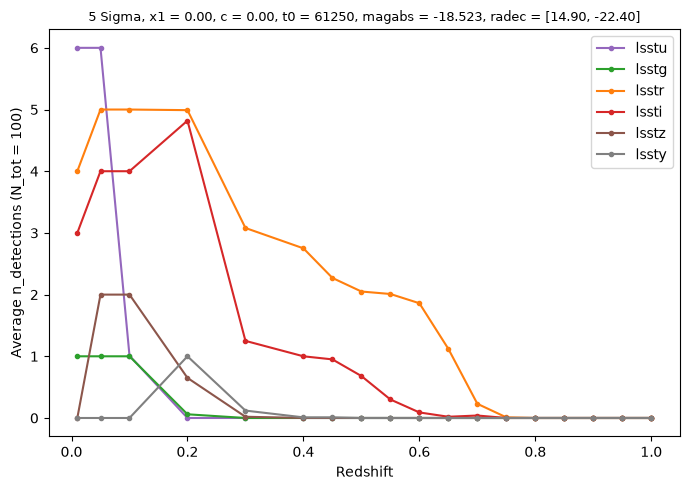

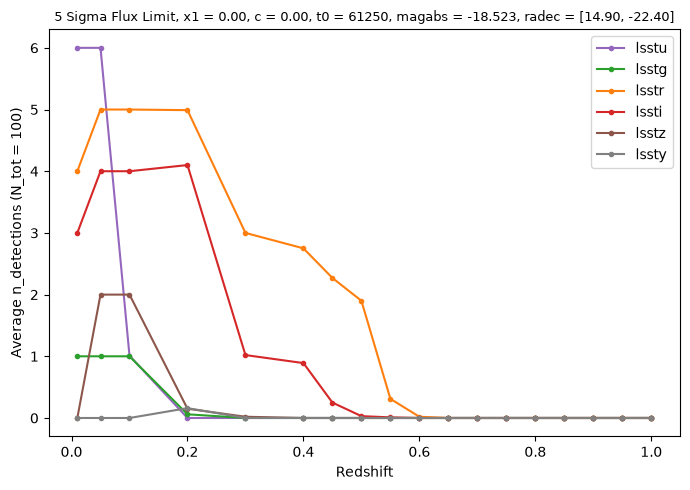

In [258]:
for condition in ["5_sigma", "5_sigma_flux_limit"]:

    fig, ax = plt.subplots(figsize=(7, 5))

    subset = final_summary[
        final_summary["condition"] == condition
    ]
    x1 = subset["x1"].iloc[0]
    c = subset["c"].iloc[0]
    t0 = subset["t0"].iloc[0]
    magabs = subset["magabs"].iloc[0]
    ra = subset["ra"].iloc[0]
    dec = subset["dec"].iloc[0]

    for band in lsst_bands:
        ax.plot(
            subset["z"],
            subset[band],
            marker=".",
            label=band,
            color=limit_mag_dict[band]["color"],
        )
        

    ax.set_xlabel("Redshift")
    ax.set_ylabel("Average n_detections (N_tot = {})".format(N_tot))
    ax.set_title(
        f"{condition.replace('_', ' ').title()}, "
        f"x1 = {x1:.2f}, c = {c:.2f}, "
        f"t0 = {t0:.0f}, magabs = {magabs:.3f}, "
        f"radec = [{ra:.2f}, {dec:.2f}]",
        fontsize=9,
    )
    ax.legend()

    plt.tight_layout()
    plt.show()

In [233]:
ra_sn = 14.9
dec_sn = -22.4

ra_obs = lsst.data["ra"].astype(float)
dec_obs = lsst.data["dec"].astype(float)

# Approximate angular separation in degrees
cos_dec = np.cos(np.deg2rad(dec_sn))

distance = np.sqrt(
    ((ra_obs - ra_sn) * cos_dec)**2
    + (dec_obs - dec_sn)**2
)

nearby_obs = lsst.data[distance < 1.0].copy()

print(len(nearby_obs))

idx = distance.idxmin()

print(lsst.data.loc[idx, ["ra", "dec", "fieldid", "fieldid_survey"]])

fieldid = lsst.data.loc[idx, "fieldid"]

field_obs = lsst.data[
    lsst.data["fieldid"] == fieldid
].copy()

field_obs.groupby("band").size()

3222
ra                    14.914061
dec                  -22.415033
fieldid           325565.000000
fieldid_survey      6741.000000
Name: 747923, dtype: float64


band
lsstg     6
lssti    13
lsstr    14
lsstu     5
lssty     7
lsstz    10
dtype: int64

In [107]:
#loop targ (total 1000)
over_limit = 0
for idx in data.index:
    #if targ is visible, call visible
    detected = 
    summed = sum(targ['flux'] >= targ['band_limitflux']) #condition 1
    if summed 
    summed_total += summed
# dset.get_ndetection(per_band = True)[8] #using iloc will metely give you row in series
print(summed_total)

0


In [101]:
dset.data.index.get_level_values(level = 1).unique() #total 54000 observations on 1000 unique obejcts

Index([  747982,   884609,  2493070,  2770824,  2772648,  2860934,  3332454,
        3429213,  3623916,  3623971,  3876993,  3880803,  4038673,  4042244,
        4111433,  4171698,  4173233,  4279680,  4283154,  4427616,  4433288,
        4707663,  4708517,  5487127,  5718513,  5718593,  5936096,  6243399,
        6246427,  6618620,  6620433,  6852296,  6853041,  6853921,  7010817,
        7013607,  7961208,  7966181,  8002340,  8756533,  8758409,  9231240,
       11416749, 11418198, 11419647, 11421096, 11729192, 11730636, 11732080,
       11733524, 11873266, 11874731, 11876196, 11877661],
      dtype='int64', name='index_obs')

In [73]:
# initiate with all bands together first i.e. how many SNIas in your simulation are visible with LSST?
total_detections =  dset.get_ndetection(per_band = False, join_bandday=False)

In [76]:
n_obs = len(total_detections)
n_obs

997

In [22]:
z_list = [0.5, 0.6, 0.7, 0.8]
n_obs_list = []
for z in z_list:
    snia_dict = generate_snia_dict(redshift = z, ra = 14.9, dec = -22.4, x1 = 0.0, t0 = 61250, magabs = -18.523, c = 0.0)
    snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
    snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = True, N_tot = 100, tstart = None, tstop = None, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)
    dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)
    total_detections = dset.get_ndetection(per_band = False, join_bandday=False)
    n_obs = len(total_detections)
    n_obs_list.append(n_obs)

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)
100%|██████████| 100/100 [00:05<00:00, 19.50it/s]


In [23]:
n_obs_list

[100, 100, 30, 0]

In [ ]:
z_list = [0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8]
n_obs = [49, 51, 50, 52, 41, 27, 1]

[0, 0]


Text(0.5, 1.0, 'N_tot = 100, 61208.20 to 61566.07 MJD, obstime 357.87d ')

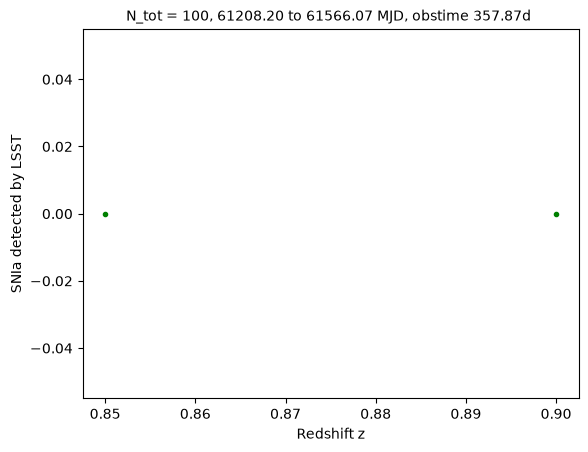

In [7]:
# This is the 3rd selection criteria with errors.
print(n_obs_list)
plt.plot(z_list, n_obs_list, 'g.', markersize = 6)
plt.xlabel('Redshift z')
plt.ylabel('SNIa detected by LSST')
plt.title(f'N_tot = 100, {tmin:.2f} to {tmax:.2f} MJD, obstime {(tmax - tmin):.2f}d', fontsize = 10)

In [ ]:
from scipy.optimize import curve_fit
z_range = np.linspace(0, 2, 100)
def line(x, m, c):
    y = m * x + c
    return y
p0 = [-1, 1]
po, cov = curve_fit(line, z_list, n_obs_list)
plt.plot(z_list, line(z_range, po[0], po[1]), 'r-')

In [143]:
coeffs = np.polyfit(z_list, n_obs_list, 3)
print(coeffs)

[  11.50464218 -122.8245962    31.10122292   49.07739941]


### Test all three selection criteria for one dset

In [20]:
snia_dict = generate_snia_dict(redshift = 0.7, ra = 40.2, dec = -22.3, x1 = 0.0, t0 = None, magabs = -18.523, c = 0.0)
snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = True, N_tot = 100, tstart = tmin, tstop = tmax, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)
dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)

NameError: name 'tmin' is not defined

In [21]:
from pprint import pprint
series = dset.get_ndetection(per_band = True, join_bandday=False)
pprint(series)

NameError: name 'dset' is not defined

In [19]:
obs = dset.get_target_lightcurve()
obs[obs['band'] == 'lsstr'] #notice all the mjd time is different

NameError: name 'dset' is not defined

In [ ]:
# use series.loc[(1, "lsstr")] due to MultiIndex

np.int64(1)

In [37]:
z_list = [0.01, 0.05, 0.2, 0.4, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9]
n_obs_list = []

cbb_z = {'0.1': {'lsstu': 39,
  'lsstg': 40,
  'lsstr': 57,
  'lssti': 42,
  'lsstz': 46,
  'lssty': 0}}

for z in z_list:
    snia_dict = generate_snia_dict(redshift = z, ra = 40.2, dec = -22.3, x1 = 0.0, t0 = None, magabs = -18.523, c = 0.0)
    snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
    snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = True, N_tot = 200, tstart = tmin, tstop = tmax, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)
    dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)
    total_detections = dset.get_ndetection(per_band = False, join_bandday=False)
    n_obs = len(total_detections)
    n_obs_list.append(n_obs)
    series = dset.get_ndetection(per_band = True, join_bandday=False)
    df = series.reset_index(name="ndetection")
    # df.head()
    filter_dfs = {
        band: df[df["band"] == band].reset_index(drop=True) #this is the masking condition
        for band in ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
    }

    # Example: show counts per band
    counts_by_band = {band: len(frame) for band, frame in filter_dfs.items()} #this will be impt

    cbb_z[f'{z}'] = counts_by_band

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)
100%|██████████| 200/200 [00:02<00:00, 66.86it/s] 
/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)
100%|██████████| 200/200 [00:01<00:00, 130.87it/s]
/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)
100%|██████████| 200/200 [00:03<00:00, 58.94it/s] 


In [50]:
cbb_z

{'0.1': {'lsstu': 39,
  'lsstg': 40,
  'lsstr': 57,
  'lssti': 42,
  'lsstz': 46,
  'lssty': 0},
 '0.01': {'lsstu': 92,
  'lsstg': 75,
  'lsstr': 104,
  'lssti': 77,
  'lsstz': 0,
  'lssty': 0},
 '0.05': {'lsstu': 92,
  'lsstg': 77,
  'lsstr': 102,
  'lssti': 79,
  'lsstz': 85,
  'lssty': 0},
 '0.2': {'lsstu': 44,
  'lsstg': 76,
  'lsstr': 105,
  'lssti': 76,
  'lsstz': 79,
  'lssty': 33},
 '0.4': {'lsstu': 0,
  'lsstg': 46,
  'lsstr': 85,
  'lssti': 54,
  'lsstz': 40,
  'lssty': 0},
 '0.6': {'lsstu': 0,
  'lsstg': 2,
  'lsstr': 45,
  'lssti': 7,
  'lsstz': 0,
  'lssty': 0},
 '0.7': {'lsstu': 0,
  'lsstg': 0,
  'lsstr': 5,
  'lssti': 2,
  'lsstz': 0,
  'lssty': 0},
 '0.75': {'lsstu': 0,
  'lsstg': 0,
  'lsstr': 3,
  'lssti': 0,
  'lsstz': 0,
  'lssty': 0},
 '0.8': {'lsstu': 0,
  'lsstg': 0,
  'lsstr': 0,
  'lssti': 0,
  'lsstz': 0,
  'lssty': 0},
 '0.85': {'lsstu': 0,
  'lsstg': 0,
  'lsstr': 0,
  'lssti': 0,
  'lsstz': 0,
  'lssty': 0},
 '0.9': {'lsstu': 0,
  'lsstg': 0,
  'lsstr': 0,

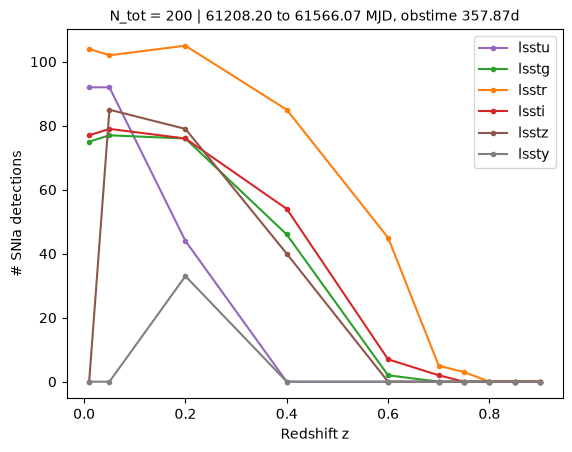

In [68]:
z_list = [0.01, 0.05, 0.2, 0.4, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9]
from lightcurve import limit_mag_dict
for band in bands:
    counts = [cbb_z[str(z)][band] for z in z_list]
    plt.plot(z_list, counts, marker=".", label=band, color = limit_mag_dict[band]["color"])

plt.xlabel("Redshift z")
plt.ylabel("# SNIa detections")
plt.title(f'N_tot = 200 | {tmin:.2f} to {tmax:.2f} MJD, obstime {(tmax - tmin):.2f}d', fontsize = 10)
plt.legend()
plt.show()

Find a SN with a lot of datapoints

We want to know on average, what are the number of detections per lightcurve per filter at a given z
So simulate random ra dec and take average.
For example, if we want min 3 datapoints in a filter, what is the max redshift we can look?

So good to fix a ra dec in a high res region.

In [15]:
# now each filter is a dict. This is for ONE redshift tho. This is still third criterion.
filter_dfs = {
    band: df[df["band"] == band].reset_index(drop=True) #this is the masking condition
    for band in ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
}

# Example: show counts per band
counts_by_band = {band: len(frame) for band, frame in filter_dfs.items()} #this will be impt
print(counts_by_band)

# Example: inspect the lsstr subset
filter_dfs["lsstg"]
for band in bands:
    print(band, filter_dfs[band].head()) 

# returns results:
print('\n redshift', 0.6,'\n', counts_by_band['lsstg'])


{'lsstu': 39, 'lsstg': 40, 'lsstr': 57, 'lssti': 42, 'lsstz': 46, 'lssty': 0}
lsstu    index   band  ndetection
0      0  lsstu           3
1      6  lsstu           2
2     10  lsstu           2
3     12  lsstu           2
4     13  lsstu           1
lsstg    index   band  ndetection
0      0  lsstg           2
1      6  lsstg           2
2      7  lsstg           2
3     10  lsstg           2
4     12  lsstg           2
lsstr    index   band  ndetection
0      0  lsstr           3
1      6  lsstr           6
2      7  lsstr           3
3      8  lsstr           3
4     10  lsstr           6
lssti    index   band  ndetection
0      0  lssti           1
1      6  lssti           1
2      7  lssti           2
3     10  lssti           2
4     12  lssti           2
lsstz    index   band  ndetection
0      0  lsstz           2
1      6  lsstz           4
2      7  lsstz           2
3     10  lsstz           6
4     12  lsstz           6
lssty Empty DataFrame
Columns: [index, band, ndetect

In [35]:
# store, for one redshift, the counts_by_band dict.
cbb_z = {}
cbb_z['0.1'] = counts_by_band

In [36]:
cbb_z

{'0.1': {'lsstu': 39,
  'lsstg': 40,
  'lsstr': 57,
  'lssti': 42,
  'lsstz': 46,
  'lssty': 0}}

In [33]:
for band, frame in filter_dfs.items():
    print(band)
    print(frame) #this is the larger dataset that records SNIa targets observed by LSST, with df index resetted

lsstu
    index   band  ndetection
0       0  lsstu           3
1       6  lsstu           2
2      10  lsstu           2
3      12  lsstu           2
4      13  lsstu           1
5      14  lsstu           1
6      18  lsstu           3
7      19  lsstu           2
8      21  lsstu           2
9      24  lsstu           1
10     28  lsstu           2
11     32  lsstu           2
12     33  lsstu           1
13     37  lsstu           2
14     39  lsstu           1
15     40  lsstu           1
16     41  lsstu           3
17     42  lsstu           1
18     43  lsstu           1
19     49  lsstu           3
20     56  lsstu           3
21     57  lsstu           1
22     58  lsstu           1
23     60  lsstu           2
24     61  lsstu           1
25     65  lsstu           4
26     66  lsstu           3
27     68  lsstu           1
28     69  lsstu           2
29     73  lsstu           2
30     74  lsstu           2
31     75  lsstu           1
32     76  lsstu           3
33     7

In [ ]:
determine_visibility()

,index,band,ndetection
0,1,lssti,1
1,1,lsstr,1


In [111]:


print(series.iloc[27])
index = series.index[0]
band_index = series.index[1]
print('max in series.values is', np.max(series.values))
np.argwhere(series.values == np.max(series.values))
# series.iloc[27]
# np.where(series.index

1
max in series.values is 3


array([[   9],
       [  10],
       [  24],
       [  32],
       [  35],
       [  61],
       [  66],
       [  73],
       [ 104],
       [ 115],
       [ 129],
       [ 133],
       [ 156],
       [ 191],
       [ 204],
       [ 235],
       [ 272],
       [ 282],
       [ 329],
       [ 333],
       [ 348],
       [ 350],
       [ 354],
       [ 366],
       [ 384],
       [ 387],
       [ 415],
       [ 425],
       [ 426],
       [ 438],
       [ 439],
       [ 478],
       [ 525],
       [ 559],
       [ 610],
       [ 615],
       [ 628],
       [ 674],
       [ 718],
       [ 729],
       [ 757],
       [ 763],
       [ 782],
       [ 822],
       [ 847],
       [ 861],
       [ 865],
       [ 877],
       [ 880],
       [ 900],
       [ 931],
       [ 942],
       [ 946],
       [ 954],
       [ 971],
       [ 982],
       [1002],
       [1010],
       [1020],
       [1027],
       [1073],
       [1091],
       [1102],
       [1112],
       [1117],
       [1131],
       [11

In [218]:
help(dset.show_target_lightcurve)

Help on method show_target_lightcurve in module skysurvey.dataset:

show_target_lightcurve(
    ax=None,
    fig=None,
    index=None,
    zp=25,
    lc_prop={},
    bands=None,
    show_truth=True,
    format_time=True,
    t0_format='mjd',
    phase_window=None,
    **kwargs
) method of skysurvey.dataset.DataSet instance
    Plot the light curve of a target.

    If `index` is None, a random index will be used. If `bands` is None,
    the target's observed band will be used.

    Parameters
    ----------
    ax : matplotlib.axes.Axes, optional
        The axes on which to plot the light curve. If None, a new figure and axes will be created.

    fig : matplotlib.figure.Figure, optional
        The figure on which to plot the light curve. If None, a new figure will be created.

    index : int, optional
        The index of the target whose light curve is to be plotted. If None, a random index is chosen.

    zp : float, optional
        Zero point magnitude for flux conversion. Defa

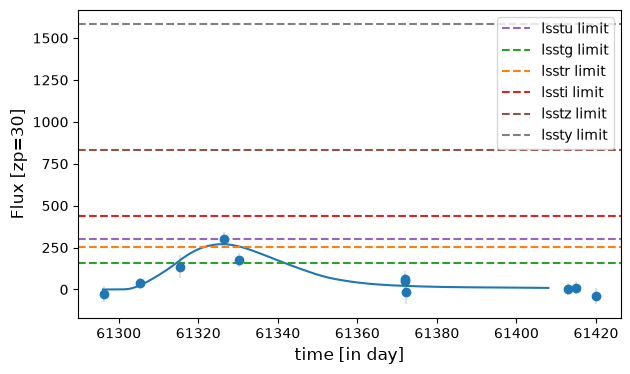

In [ ]:
# detectopm = 5sigma
# fig, ax = plt.subplots(1,1)
dset.show_target_lightcurve(index = 1, phase_window=[-60,200], zp = 30, bands = ['lsstr'], format_time = False)
# plt.xlim(61321, 61322)
ax = plt.gca()
for band in bands:
    ax.axhline(
        limit_mag_dict[band]["flux"],
        color=limit_mag_dict[band]["color"],
        linestyle="--",
        label=f"{band} limit",
    )
ax.legend()
# ax.set_ylim(163,164)
# ax.set_xlim(61312, 61318)

#recall the phase range is the range within we define our model lightcurve

In [64]:
# Criteria 1: Is it observable? Perhaps include this column in a combined parquet with the Criteria 3.
z_list = [0.1]
n_obs_list_test = []
cbb_z_test = {}

for z in z_list:
    snia_dict = generate_snia_dict(redshift = z, ra = 40.2, dec = -22.3, x1 = 0.0, t0 = None, magabs = -18.523, c = 0.0)
    snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
    snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = True, N_tot = 200, tstart = tmin, tstop = tmax, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)
    dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)
    total_detections = dset.get_ndetection(per_band = False, join_bandday=False)
    n_obs = len(total_detections)
    n_obs_list_test.append(n_obs)
    series = dset.get_ndetection(per_band = True, join_bandday=False)
    df = series.reset_index(name="ndetection")
    # df.head()
    filter_dfs = {
        band: df[df["band"] == band].reset_index(drop=True) #this is the masking condition
        for band in ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
    }

    # Example: show counts per band
    counts_by_band = {band: len(frame) for band, frame in filter_dfs.items()} #this will be impt

    cbb_z_test[f'{z}'] = counts_by_band

snia_models.data

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)
100%|██████████| 200/200 [00:02<00:00, 84.82it/s] 


,z,x1,c,t0,magabs,ra,dec,magobs,template
0,0.1,0.0,0.0,61396.839844,-18.523001,40.200001,-22.299999,19.864223,salt2
1,0.1,0.0,0.0,61536.656250,-18.523001,40.200001,-22.299999,19.864223,salt2
2,0.1,0.0,0.0,61478.531250,-18.523001,40.200001,-22.299999,19.864223,salt2
3,0.1,0.0,0.0,61238.214844,-18.523001,40.200001,-22.299999,19.864223,salt2
4,0.1,0.0,0.0,61516.699219,-18.523001,40.200001,-22.299999,19.864223,salt2
...,...,...,...,...,...,...,...,...,...
195,0.1,0.0,0.0,61429.542969,-18.523001,40.200001,-22.299999,19.864223,salt2
196,0.1,0.0,0.0,61329.675781,-18.523001,40.200001,-22.299999,19.864223,salt2
197,0.1,0.0,0.0,61339.203125,-18.523001,40.200001,-22.299999,19.864223,salt2
198,0.1,0.0,0.0,61252.144531,-18.523001,40.200001,-22.299999,19.864223,salt2


In [66]:
data_models[1]

{'times': array([61516.65625   , 61516.79653056, 61516.93681112, 61517.07709168,
        61517.21737224, 61517.35765281, 61517.49793337, 61517.63821393,
        61517.77849449, 61517.91877505, 61518.05905561, 61518.19933617,
        61518.33961673, 61518.47989729, 61518.62017786, 61518.76045842,
        61518.90073898, 61519.04101954, 61519.1813001 , 61519.32158066,
        61519.46186122, 61519.60214178, 61519.74242234, 61519.88270291,
        61520.02298347, 61520.16326403, 61520.30354459, 61520.44382515,
        61520.58410571, 61520.72438627, 61520.86466683, 61521.00494739,
        61521.14522796, 61521.28550852, 61521.42578908, 61521.56606964,
        61521.7063502 , 61521.84663076, 61521.98691132, 61522.12719188,
        61522.26747244, 61522.40775301, 61522.54803357, 61522.68831413,
        61522.82859469, 61522.96887525, 61523.10915581, 61523.24943637,
        61523.38971693, 61523.52999749, 61523.67027806, 61523.81055862,
        61523.95083918, 61524.09111974, 61524.2314003 ,

In [43]:
# perhaps optional: for every index (prob very heavy)
obs = dset.get_target_lightcurve(index=3)
print(obs.columns)
print(obs[["band", "mjd", "flux", "fluxerr", "zp"]])

NameError: name 'dset' is not defined

In [41]:
from skysurvey.config import get_band_color

bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]

print(get_band_color(bands))

[None, None, None, None, None, None]


In [185]:
print(obs[obs["band"] == "lssti"])

                    mjd   band    skynoise  gain  zp  fieldid        flux  \
index_obs                                                                   
4498081    61315.335938  lssti   70.519104     1  30   331110  163.660189   
5136919    61324.378906  lssti   84.697784     1  30   331110  397.150022   
5372465    61330.222656  lssti   54.827576     1  30   331110  320.206969   
5849996    61343.273438  lssti   70.383858     1  30   331110  136.535177   
7023889    61366.191406  lssti  134.558014     1  30   331110  -45.206746   
8394570    61394.128906  lssti   68.646149     1  30   331110   16.971908   

              fluxerr  
index_obs              
4498081     71.761836  
5136919     86.335941  
5372465     57.344048  
5849996     71.724453  
7023889    134.778585  
8394570     68.819681  


NameError: name 'dset' is not defined

In [192]:
obs = dset.get_data(index=1, zp=30).copy()

obs["threshold"] = 5 * obs["fluxerr"]
obs

,mjd,band,skynoise,gain,zp,fieldid,flux,fluxerr,threshold
index_obs,,,,,,,,,
2596757,61251.386719,lssty,202.305313,1,30,331110,193.632987,202.305317,1011.526586
3549467,61294.410156,lsstz,199.521988,1,30,331110,46.530186,199.521987,997.609937
3719679,61296.406250,lsstr,46.684544,1,30,331110,-26.502474,46.684681,233.423403
4187965,61303.230469,lssty,278.196136,1,30,331110,101.359442,278.219190,1391.095948
4190428,61303.238281,lssty,307.322113,1,30,331110,-304.455674,307.343059,1536.715296
4210849,61304.246094,lssty,190.099640,1,30,331110,99.934681,190.152483,950.762417
4211066,61304.246094,lssty,191.964066,1,30,331110,-124.436517,192.016393,960.081963
4211468,61304.246094,lssty,186.095703,1,30,331110,-184.018410,186.149674,930.748372
4293692,61305.234375,lsstz,96.023933,1,30,331110,133.212880,96.201525,481.007623


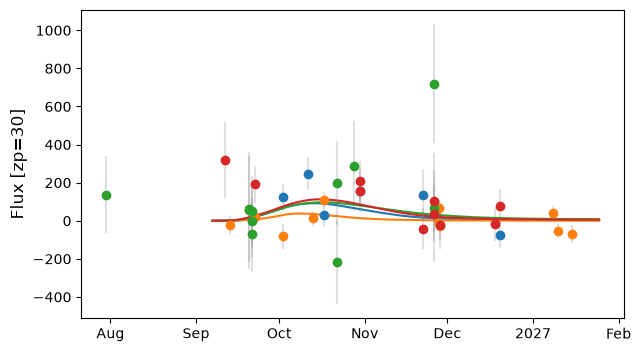

In [ ]:
# detectopm = 5sigma
fig = dset.show_target_lightcurve(index=0, phase_window=None, zp = 30)

In [ ]:
from skysurvey.config import get_band_color

import inspect

print(inspect.getsource(get_band_color))

In [41]:
# flux to mag using zpf = 25: result[i] = -2.5 * np.log10(f / zpf)

#zpf =/= zp = 25

import numpy as np

def flux_to_mag(flux, zp=30):
    return zp - 2.5*np.log10(flux)

def mag_to_flux(mag, zp=30):
    return 10**(-0.4*(mag-zp))

In [42]:
limit_mag_dict = {
    "lsstu": {"mag": 23.8, "color": "tab:purple"},
    "lsstg": {"mag": 24.5, "color": "tab:green"},
    "lsstr": {"mag": 24.0, "color": "tab:orange"},
    "lssti": {"mag": 23.4, "color": "tab:red"},
    "lsstz": {"mag": 22.7, "color": "tab:brown"},
    "lssty": {"mag": 22.0, "color": "0.5"},
}

# Convert each band limit from magnitude to flux using zp=30
limit_flux_dict = {
    band: {
        "mag": info["mag"],
        "flux": round(mag_to_flux(info["mag"], zp=31.4), 3),
        "color": info["color"],
    }
    for band, info in limit_mag_dict.items()
}

limit_flux_dict

{'lsstu': {'mag': 23.8, 'flux': 1096.478, 'color': 'tab:purple'},
 'lsstg': {'mag': 24.5, 'flux': 575.44, 'color': 'tab:green'},
 'lsstr': {'mag': 24.0, 'flux': 912.011, 'color': 'tab:orange'},
 'lssti': {'mag': 23.4, 'flux': 1584.893, 'color': 'tab:red'},
 'lsstz': {'mag': 22.7, 'flux': 3019.952, 'color': 'tab:brown'},
 'lssty': {'mag': 22.0, 'flux': 5754.399, 'color': '0.5'}}